In [1]:
import pandas as pd

# Load the blood cell anomaly detection dataset
df = pd.read_csv('data/dataset/blood_cell_anomaly_detection.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (5880, 36)
Columns: ['cell_id', 'cell_type', 'anomaly_label', 'disease_category', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl', 'dataset_source', 'staining_protocol', 'microscope_model', 'magnification_x', 'image_resolution_px', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']

First 5 rows:


,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [2]:
import numpy as np

# Identify numerical and qualitative columns
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
qualitative_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:", numerical_columns)
print("\nQualitative columns:", qualitative_columns)
print("\nExample row:")
df.iloc[0]

Numerical columns: ['anomaly_label', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl', 'magnification_x', 'image_resolution_px', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']

Qualitative columns: ['cell_id', 'cell_type', 'disease_category', 'patient_age_group', 'patient_sex', 'dataset_source', 'staining_protocol', 'microscope_model']

Example row:


C:\Users\rvazq\AppData\Local\Temp\ipykernel_16232\1105893473.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qualitative_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()


cell_id                                                  CELL_005371
cell_type                                  Hypersegmented_Neutrophil
anomaly_label                                                      1
disease_category                                           Infection
cell_diameter_um                                               15.18
nucleus_area_pct                                                58.8
chromatin_density                                              0.542
cytoplasm_ratio                                                0.301
circularity                                                    0.563
eccentricity                                                   0.529
granularity_score                                               4.11
lobularity_score                                                 6.6
membrane_smoothness                                              0.8
cell_area_px                                                     445
perimeter_px                      

In [3]:
# Drop unnecessary columns
columns_to_drop = ['cell_area_px', 'perimeter_px', 'cell_id', 'magnification_x', 'image_resolution_px', 'labeller_confidence_score', 'cytodiffusion_classification_confidence', 'microscope_model', 'stain_intensity', 'mean_r', 'mean_g', 'mean_b', 'dataset_source', 'staining_protocol', 'cytodiffusion_anomaly_score']
df.drop(columns=columns_to_drop, inplace=True)

print("Columns after dropping:", list(df.columns))
print("New shape:", df.shape)

Columns after dropping: ['cell_type', 'anomaly_label', 'disease_category', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl']
New shape: (5880, 21)


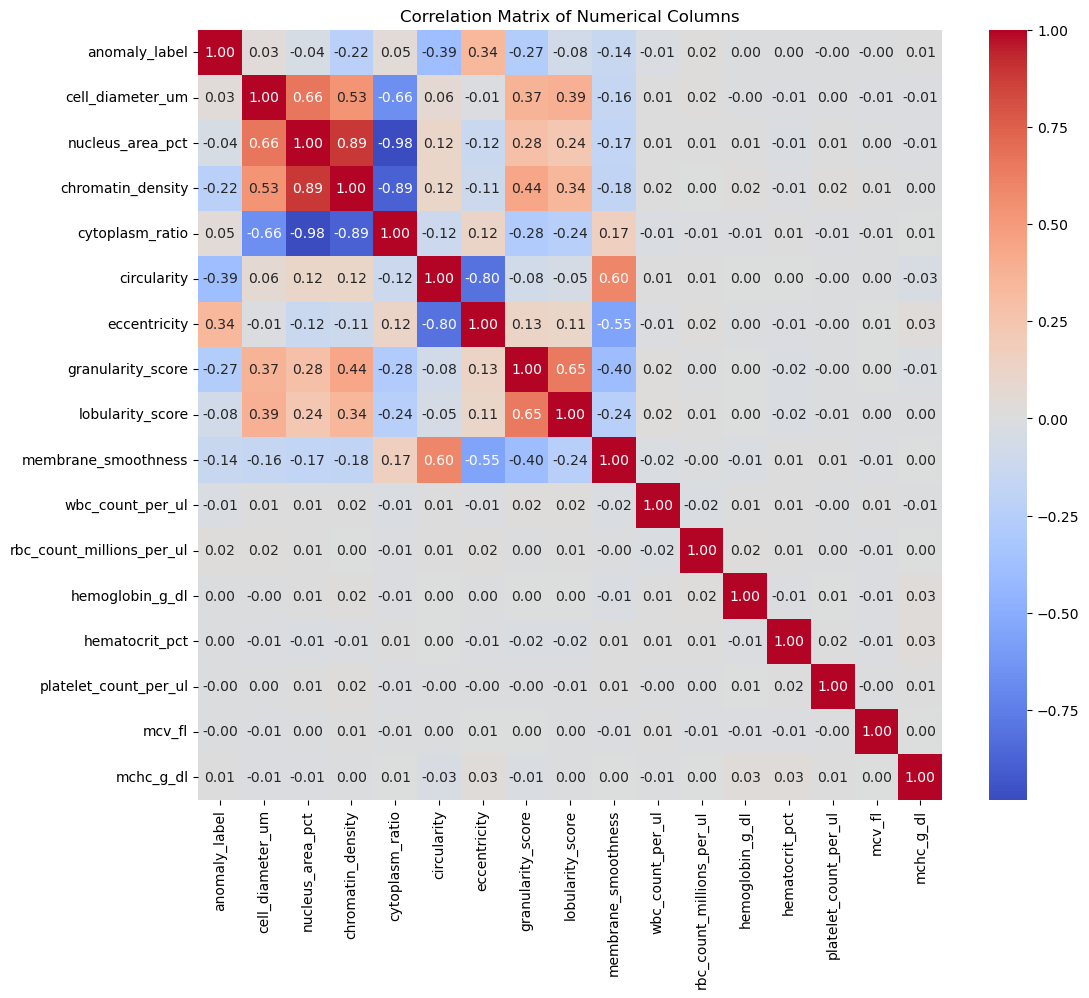

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Update numerical columns after dropping
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr_matrix = df[numerical_columns].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Update qualitative columns after dropping
qualitative_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
print(df[numerical_columns].describe())

# Unique values for qualitative columns
for col in qualitative_columns:
    print(f"\nUnique values in {col}: {df[col].nunique()}")
    print(df[col].value_counts().head(10))  # Show top 10 to avoid too much output

Missing values per column:
cell_type                    0
anomaly_label                0
disease_category             0
cell_diameter_um             0
nucleus_area_pct             0
chromatin_density            0
cytoplasm_ratio              0
circularity                  0
eccentricity                 0
granularity_score            0
lobularity_score             0
membrane_smoothness          0
patient_age_group            0
patient_sex                  0
wbc_count_per_ul             0
rbc_count_millions_per_ul    0
hemoglobin_g_dl              0
hematocrit_pct               0
platelet_count_per_ul        0
mcv_fl                       0
mchc_g_dl                    0
dtype: int64

Total missing values: 0

Number of duplicate rows: 0

Summary statistics for numerical columns:
       anomaly_label  cell_diameter_um  nucleus_area_pct  chromatin_density  \
count    5880.000000       5880.000000       5880.000000        5880.000000   
mean        0.319728         10.176267         43.5379

C:\Users\rvazq\AppData\Local\Temp\ipykernel_16232\3479281138.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qualitative_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [6]:
# Count of all cell type classes
print("Count of all cell type classes:")
print(df['cell_type'].value_counts())

Count of all cell type classes:
cell_type
Neutrophil                   1100
Normal_RBC                    900
Lymphocyte                    850
Monocyte                      400
Platelet                      300
Eosinophil                    300
Blast_Cell                    280
Elliptocyte                   200
Prolymphocyte                 180
Schistocyte                   170
Hypersegmented_Neutrophil     160
Reactive_Lymphocyte           150
Basophil                      150
Spherocyte                    150
Toxic_Granulation             140
Sickle_Cell                   140
Target_Cell                   130
Smudge_Cell                   100
Artefact                       80
Name: count, dtype: int64
